## Setup and Imports

Load required libraries for regression modeling, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor

## Load Processed Data

Load the enriched dataset containing race results, performance features, and environmental variables.

In [2]:
df = pd.read_csv("data_processed/f1_master_enriched.csv")

df["date"] = pd.to_datetime(df["date"])
df.head()

/var/folders/cg/wc2pq_yj52nbzwtdflk50zzc0000gn/T/ipykernel_97131/1215598214.py:1: DtypeWarning: Columns (0: number_x) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_processed/f1_master_enriched.csv")


,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,temp_max,temp_min,precipitation,wind_speed,humidity_avg,month,temp_range,is_wet_race,abs_lat,high_altitude_track
0,1,18,1,1,22,1,1,1,1,10.0,...,38.4,18.1,0.0,23.1,41.0,3,20.3,0,37.8497,0
1,2,18,2,2,3,5,2,2,2,8.0,...,38.4,18.1,0.0,23.1,41.0,3,20.3,0,37.8497,0
2,3,18,3,3,7,7,3,3,3,6.0,...,38.4,18.1,0.0,23.1,41.0,3,20.3,0,37.8497,0
3,4,18,4,4,5,11,4,4,4,5.0,...,38.4,18.1,0.0,23.1,41.0,3,20.3,0,37.8497,0
4,5,18,5,1,23,3,5,5,5,4.0,...,38.4,18.1,0.0,23.1,41.0,3,20.3,0,37.8497,0


## Define Target Variable

Define finishing position as the regression target using position order.

In [3]:
df["finish_position"] = df["positionOrder"]

## Target Distribution

Examine the distribution of finishing positions to understand shape and spread.

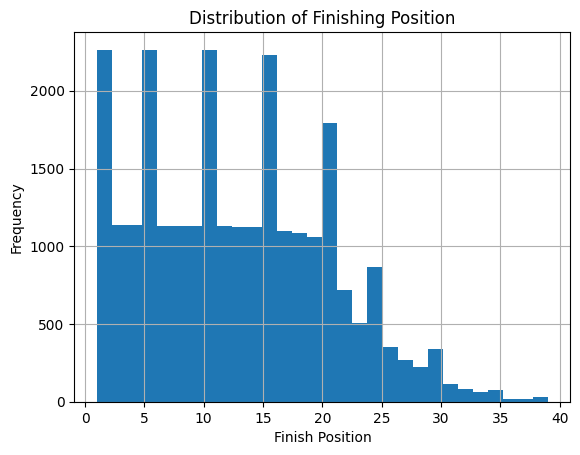

In [4]:
plt.figure()
df["finish_position"].hist(bins=30)
plt.title("Distribution of Finishing Position")
plt.xlabel("Finish Position")
plt.ylabel("Frequency")
plt.show()

## Feature Selection

Select numerical features capturing starting position, performance, reliability, and environmental conditions.

In [6]:
[c for c in df.columns if "grid" in c.lower() or "qual" in c.lower() or "dnf" in c.lower() or "points_last" in c.lower() or "finish_last" in c.lower()]

['grid', 'quali_date', 'quali_time']

In [5]:
features = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "constructor_points_last5",
    "driver_dnf_rate_last5",
    "constructor_dnf_rate_last5",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

model_df = df[["finish_position"] + features].copy()

# ensure numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna()

model_df.shape

KeyError: "['grid_clean', 'qualifying_position', 'driver_avg_finish_last5', 'constructor_points_last5', 'driver_dnf_rate_last5', 'constructor_dnf_rate_last5'] not in index"

## Train-Test Split

Use a time-based split to simulate real-world prediction.

In [ ]:
train = model_df[df["year"] <= 2021]
test = model_df[df["year"] >= 2022]

X_train = train[features]
y_train = train["finish_position"]

X_test = test[features]
y_test = test["finish_position"]

X_train.shape, X_test.shape